<a href="https://colab.research.google.com/github/R3tromancer/Dynamic-Fall-detection---GSTCAN/blob/main/GSTCAN%20RTMpose%20XUR%20Fall%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# FINAL GSTCAN — RTMPOSE-X + URFD
# Based on Egawa et al., Electronics 2023, 12, 3234
# ============================================================
#
# Main design choices retained from the paper/code:
#   - URFD: 70 sequences (30 fall, 40 ADL)
#   - 13-joint representation
#   - frame-to-frame 2D motion
#   - 3 spatial graph partitions: root, centripetal, centrifugal
#   - six GSTCAN units
#   - channels: 64, 64, 128, 128, 256, 256
#   - temporal kernel = 9
#   - channel attention after each GSTCN unit
#   - concatenation skip connection
#   - dropout = 0.5
#   - RMSprop, learning rate = 0.001
#   - batch size = 32
#   - 100 epochs
#   - 3-fold sequence-level cross-validation
#   - test set evaluated every epoch, following the paper's pseudocode
#
# Requested modifications:
#   - RTMPose-X instead of AlphaPose
#   - minimum valid-joint ratio = 0.70 (configurable)
#   - no coordinate normalization in preprocessing
#   - no unused geometric filtering pipeline
#   - no redundant definitions/tests/imports
#
# IMPORTANT:
#   The paper does NOT publish the exact fold indices. It states 3-fold
#   cross-validation and also describes a 70%/30% train/test split in its
#   pseudocode. Therefore exact reproduction of the authors' hidden fold
#   membership is impossible from the paper alone. This implementation uses
#   deterministic StratifiedKFold(n_splits=3, shuffle=True, random_state=42).
# ============================================================

# ============================================================


In [ ]:
# CELL 1 — INSTALL ENVIRONMENT
# ============================================================

!pip install -q -U rtmlib beautifulsoup4 requests tqdm scikit-learn matplotlib
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q --no-cache-dir onnxruntime-gpu==1.26.0

print("Installation complete.")


# ============================================================


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 54.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━

In [ ]:
# CELL 2 — IMPORTS AND CONFIGURATION
# ============================================================

import sys
import os
import re
import time
import pickle
import zipfile
import random
import requests

from pathlib import Path
from urllib.parse import urljoin
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from rtmlib import Body


# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# -----------------------------
# Dataset / filesystem
# -----------------------------
DATASET_PAGE = "https://fenix.ur.edu.pl/~mkepski/ds/uf.html"
BASE_URL = "https://fenix.ur.edu.pl/~mkepski/ds/"

ROOT = Path("/content/URFD")
ZIP_DIR = ROOT / "zips"
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
CHECKPOINT_DIR = ROOT / "checkpoints_gstcan_fullseq"
RESULTS_DIR = ROOT / "results_gstcan_fullseq"

for directory in [
    ROOT,
    ZIP_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# -----------------------------
# RTMPose-X
# -----------------------------
DEVICE = "cuda"
BACKEND = "onnxruntime"

DET_INPUT_SIZE = (640, 640)
POSE_INPUT_SIZE = (288, 384)


# -----------------------------
# Pose filtering
# -----------------------------
POSE_CONF_THRESHOLD = 0.20

# NEW: a frame is retained when at least this fraction of the 13 joints
# has confidence >= POSE_CONF_THRESHOLD.
# Initial value requested by user: 70%.
MIN_VALID_JOINT_RATIO = 0.70

# Changes to any value in this signature force processed checkpoints to be
# regenerated instead of silently reusing incompatible old preprocessing.
PROCESSING_SIGNATURE = {
    "pose_confidence_threshold": POSE_CONF_THRESHOLD,
    "minimum_valid_joint_ratio": MIN_VALID_JOINT_RATIO,
    "coordinate_normalization": False,
    "num_joints": 13,
}

# Set True for a clean reproduction from the downloaded ZIP archives.
# This avoids accidentally reusing a raw directory from an earlier run in
# which frames may already have been deleted.
FORCE_REEXTRACT_RAW = True


# -----------------------------
# GSTCAN model/training
# -----------------------------
FINAL_EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
DROPOUT = 0.5
TEMPORAL_KERNEL = 9
GSTCAN_CHANNELS = [64, 64, 128, 128, 256, 256]
NUM_CLASSES = 2
NUM_JOINTS = 13


# ============================================================


In [ ]:
# CELL 3 — VERIFY ENVIRONMENT
# ============================================================

print("Python       :", sys.version)
print("PyTorch      :", torch.__version__)
print("PyTorch CUDA :", torch.version.cuda)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

print("ONNX Runtime :", ort.__version__)
print("Providers    :", ort.get_available_providers())

assert torch.cuda.is_available(), "CUDA is not available."
assert "CUDAExecutionProvider" in ort.get_available_providers(), (
    "CUDAExecutionProvider is not available."
)
assert ort.__version__ == "1.26.0", (
    f"Expected ONNX Runtime 1.26.0, got {ort.__version__}"
)

print("Environment verification PASSED.")


# ============================================================


Python       : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch      : 2.11.0+cu128
PyTorch CUDA : 12.8
CUDA         : True
GPU          : Tesla T4
ONNX Runtime : 1.26.0
Providers    : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Environment verification PASSED.


In [ ]:
# CELL 4 — CREATE RTMPOSE-X
# ============================================================

pose_model = Body(
    det=(
        "https://download.openmmlab.com/"
        "mmpose/v1/projects/rtmposev1/"
        "onnx_sdk/"
        "yolox_x_8xb8-300e_humanart-a39d44ed.zip"
    ),
    det_input_size=DET_INPUT_SIZE,
    pose=(
        "https://download.openmmlab.com/"
        "mmpose/v1/projects/rtmposev1/"
        "onnx_sdk/"
        "rtmpose-x_simcc-body7_pt-body7_700e-"
        "384x288-71d7b7e9_20230629.zip"
    ),
    pose_input_size=POSE_INPUT_SIZE,
    backend=BACKEND,
    device=DEVICE,
    to_openpose=False,
)

det_providers = pose_model.det_model.session.get_providers()
pose_providers = pose_model.pose_model.session.get_providers()

assert "CUDAExecutionProvider" in det_providers, (
    "YOLOX detector is not using CUDAExecutionProvider."
)
assert "CUDAExecutionProvider" in pose_providers, (
    "RTMPose-X is not using CUDAExecutionProvider."
)

print("RTMPose-X ready on CUDA.")


# ============================================================


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/yolox_x_8xb8-300e_humanart-a39d44ed.zip" to /root/.cache/rtmlib/hub/checkpoints/yolox_x_8xb8-300e_humanart-a39d44ed.zip
100%|██████████| 351M/351M [00:28<00:00, 13.0MB/s]


load /root/.cache/rtmlib/hub/checkpoints/yolox_x_8xb8-300e_humanart-a39d44ed.onnx with onnxruntime backend


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.zip
100%|██████████| 176M/176M [00:14<00:00, 12.5MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.onnx with onnxruntime backend
RTMPose-X ready on CUDA.


In [ ]:
# CELL 5 — DOWNLOAD URFD CAMERA-0 RGB ARCHIVES
# ============================================================

response = requests.get(
    DATASET_PAGE,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60,
)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

urls = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if re.search(
        r"(fall|adl)-\d+-cam0-rgb\.zip$",
        href,
        flags=re.IGNORECASE,
    ):
        urls.append(urljoin(BASE_URL, href))

urls = sorted(set(urls))
fall_urls = [u for u in urls if "/fall-" in u]
adl_urls = [u for u in urls if "/adl-" in u]

assert len(fall_urls) == 30, f"Expected 30 fall archives, found {len(fall_urls)}"
assert len(adl_urls) == 40, f"Expected 40 ADL archives, found {len(adl_urls)}"
assert len(urls) == 70, f"Expected 70 archives, found {len(urls)}"


def download_file(url: str) -> Path:
    filename = os.path.basename(url)
    output = ZIP_DIR / filename

    if output.exists() and output.stat().st_size > 0:
        return output

    temporary = output.with_suffix(output.suffix + ".part")

    with requests.get(
        url,
        stream=True,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=180,
    ) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(temporary, "wb") as f:
            with tqdm(
                total=total,
                unit="B",
                unit_scale=True,
                desc=filename,
                leave=False,
            ) as pbar:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

    temporary.replace(output)
    return output


with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(download_file, url) for url in urls]
    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Downloading URFD",
    ):
        future.result()

print("URFD download complete.")


# ============================================================


adl-03-cam0-rgb.zip:   0%|          | 0.00/84.4M [00:00<?, ?B/s]

adl-01-cam0-rgb.zip:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

adl-02-cam0-rgb.zip:   0%|          | 0.00/83.5M [00:00<?, ?B/s]

adl-04-cam0-rgb.zip:   0%|          | 0.00/70.7M [00:00<?, ?B/s]

adl-05-cam0-rgb.zip:   0%|          | 0.00/85.3M [00:00<?, ?B/s]

...

fall-27-cam0-rgb.zip:   0%|          | 0.00/29.9M [00:00<?, ?B/s]

fall-28-cam0-rgb.zip:   0%|          | 0.00/21.5M [00:00<?, ?B/s]

fall-29-cam0-rgb.zip:   0%|          | 0.00/31.9M [00:00<?, ?B/s]

fall-30-cam0-rgb.zip:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

URFD download complete.


In [ ]:
# CELL 6 — EXTRACT RGB FRAMES
# ============================================================

zip_files = sorted(ZIP_DIR.glob("*.zip"))
assert len(zip_files) == 70, f"Expected 70 archives, found {len(zip_files)}"

for zip_path in tqdm(zip_files, desc="Extracting URFD"):
    sequence_name = zip_path.stem.replace("-cam0-rgb", "")
    output_dir = RAW_DIR / sequence_name

    if FORCE_REEXTRACT_RAW and output_dir.exists():
        import shutil
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    existing = list(output_dir.rglob("*.png"))
    if existing and not FORCE_REEXTRACT_RAW:
        continue

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(output_dir)

sequence_names = sorted(
    p.name
    for p in RAW_DIR.iterdir()
    if p.is_dir() and (p.name.startswith("fall-") or p.name.startswith("adl-"))
)

assert len(sequence_names) == 70, (
    f"Expected 70 URFD sequences, found {len(sequence_names)}"
)

raw_frame_count = sum(1 for _ in RAW_DIR.rglob("*.png"))
assert raw_frame_count > 0, "No RGB frames were extracted."

print("Sequences:", len(sequence_names))
print("RGB frames:", raw_frame_count)


# ============================================================


Extracting URFD:   0%|          | 0/70 [00:00<?, ?it/s]

Sequences: 70
RGB frames: 11936


AVAILABLE SEQUENCES
[00] adl-01
[01] adl-02
[02] adl-03
[03] adl-04
[04] adl-05
[05] adl-06
[06] adl-07
[07] adl-08
[08] adl-09
[09] adl-10
[10] adl-11
[11] adl-12
[12] adl-13
[13] adl-14
[14] adl-15
[15] adl-16
[16] adl-17
[17] adl-18
[18] adl-19
[19] adl-20
[20] adl-21
[21] adl-22
[22] adl-23
[23] adl-24
[24] adl-25
[25] adl-26
[26] adl-27
[27] adl-28
[28] adl-29
[29] adl-30
[30] adl-31
[31] adl-32
[32] adl-33
[33] adl-34
[34] adl-35
[35] adl-36
[36] adl-37
[37] adl-38
[38] adl-39
[39] adl-40
[40] fall-01
[41] fall-02
[42] fall-03
[43] fall-04
[44] fall-05
[45] fall-06
[46] fall-07
[47] fall-08
[48] fall-09
[49] fall-10
[50] fall-11
[51] fall-12
[52] fall-13
[53] fall-14
[54] fall-15
[55] fall-16
[56] fall-17
[57] fall-18
[58] fall-19
[59] fall-20
[60] fall-21
[61] fall-22
[62] fall-23
[63] fall-24
[64] fall-25
[65] fall-26
[66] fall-27
[67] fall-28
[68] fall-29
[69] fall-30

Total sequences available: 70

Selected sequence:
    fall-30

Frames found: 70

Valid frame indices: 0 to 69

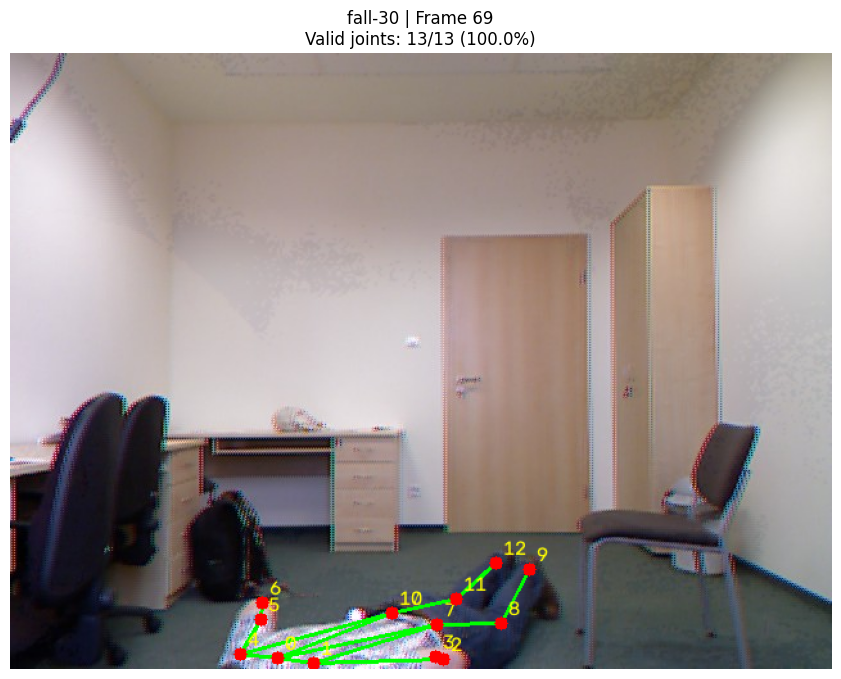

In [ ]:
# ============================================================
# CELL 8 — TEST RTMPOSE-X ON ONE SELECTED VIDEO / FRAME
# ============================================================
#
# PURPOSE:
#   Test pose extraction manually before processing all 70 sequences.
#
#   You can freely choose:
#       1. Which video/sequence to inspect
#       2. Which frame to inspect
#
#   The cell:
#       - lists all downloaded sequences
#       - lets you select one
#       - lists its frames
#       - lets you select one frame
#       - runs RTMPose-X
#       - converts COCO-17 -> GSTCAN 13 joints
#       - displays the frame with the skeleton drawn
#       - prints joint coordinates and confidence scores
#
# IMPORTANT:
#   This does NOT modify the dataset and does NOT save anything.
#   It is only a visual/debugging test.
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. FIND ALL DOWNLOADED SEQUENCES
# ------------------------------------------------------------

available_sequences = sorted(
    p.name
    for p in RAW_DIR.iterdir()
    if p.is_dir()
    and (
        p.name.startswith("fall-")
        or p.name.startswith("adl-")
    )
)

assert available_sequences, (
    f"No sequences found in {RAW_DIR}"
)

print("=" * 70)
print("AVAILABLE SEQUENCES")
print("=" * 70)

for i, sequence_name in enumerate(available_sequences):
    print(f"[{i:02d}] {sequence_name}")

print()
print(f"Total sequences available: {len(available_sequences)}")


# ------------------------------------------------------------
# 2. CHOOSE A VIDEO / SEQUENCE
# ------------------------------------------------------------

sequence_choice = 69


assert 0 <= sequence_choice < len(available_sequences), (
    "Invalid sequence number."
)

selected_sequence = available_sequences[sequence_choice]

sequence_dir = RAW_DIR / selected_sequence

print()
print("Selected sequence:")
print("   ", selected_sequence)


# ------------------------------------------------------------
# 3. FIND ALL FRAMES IN THAT SEQUENCE
# ------------------------------------------------------------

frame_paths = sorted(
    sequence_dir.rglob("*.png")
)

assert frame_paths, (
    f"No PNG frames found in {sequence_dir}"
)

print()
print(f"Frames found: {len(frame_paths)}")


# ------------------------------------------------------------
# 4. CHOOSE A FRAME
# ------------------------------------------------------------
#
# FRAME NUMBER IS ZERO-BASED:
#
#   0 = first frame
#   1 = second frame
#   2 = third frame
#   ...
#
# You can enter any valid frame index.
# ------------------------------------------------------------

print(
    f"\nValid frame indices: "
    f"0 to {len(frame_paths) - 1}"
)

frame_choice = 69

assert 0 <= frame_choice < len(frame_paths), (
    "Invalid frame number."
)

selected_frame_path = frame_paths[frame_choice]

print()
print("Selected frame:")
print("   ", selected_frame_path)


# ------------------------------------------------------------
# 5. LOAD FRAME
# ------------------------------------------------------------

frame_bgr = cv2.imread(
    str(selected_frame_path)
)

assert frame_bgr is not None, (
    f"Could not read frame: {selected_frame_path}"
)

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)


# ------------------------------------------------------------
# 6. RUN RTMPOSE-X
# ------------------------------------------------------------
#
# Body() returns:
#
#   keypoints : detected COCO-17 coordinates
#   scores    : confidence score for each joint
#
# ------------------------------------------------------------

keypoints, scores = pose_model(frame_rgb)


print()
print("=" * 70)
print("RTMPOSE-X OUTPUT")
print("=" * 70)

print("Keypoints shape:", np.asarray(keypoints).shape)
print("Scores shape   :", np.asarray(scores).shape)


# ------------------------------------------------------------
# 7. HANDLE MULTIPLE DETECTED PEOPLE
# ------------------------------------------------------------
#
# RTMPose-X can detect more than one person.
#
# For GSTCAN we need one person.
# We therefore select the person with the highest
# mean confidence.
# ------------------------------------------------------------

keypoints = np.asarray(
    keypoints,
    dtype=np.float32
)

scores = np.asarray(
    scores,
    dtype=np.float32
)

if keypoints.ndim == 2:
    # Only one person detected
    keypoints = keypoints[None, ...]
    scores = scores[None, ...]

num_people = keypoints.shape[0]

print("People detected:", num_people)


if num_people == 0:
    print()
    print("NO PERSON DETECTED.")
    print("Try another frame.")
else:

    # Mean confidence for each detected person
    person_confidences = np.mean(
        scores,
        axis=1
    )

    best_person = int(
        np.argmax(person_confidences)
    )

    best_keypoints = keypoints[best_person]
    best_scores = scores[best_person]

    print(
        f"Selected person: {best_person}"
    )

    print(
        "Mean confidence:",
        float(person_confidences[best_person])
    )


    # --------------------------------------------------------
    # 8. CONVERT COCO-17 -> GSTCAN 13 JOINTS
    # --------------------------------------------------------

    points13, scores13 = coco17_to_gstcan13(
        best_keypoints,
        best_scores
    )

    joint_valid = valid_joint_mask(
        scores13
    )

    valid_count = int(
        np.sum(joint_valid)
    )

    valid_ratio = float(
        np.mean(joint_valid)
    )


    # --------------------------------------------------------
    # 9. PRINT GSTCAN JOINT INFORMATION
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("GSTCAN 13-JOINT RESULT")
    print("=" * 70)

    print(
        f"Valid joints: "
        f"{valid_count}/13 "
        f"({valid_ratio * 100:.1f}%)"
    )

    print(
        f"Minimum required ratio: "
        f"{MIN_VALID_JOINT_RATIO * 100:.1f}%"
    )

    print(
        "Frame accepted:",
        valid_ratio >= MIN_VALID_JOINT_RATIO
    )

    print()
    print(
        f"{'Joint':<20} "
        f"{'X':>10} "
        f"{'Y':>10} "
        f"{'Confidence':>12} "
        f"{'Valid':>8}"
    )

    print("-" * 70)

    for joint_name, point, score, valid in zip(
        JOINT_NAMES,
        points13,
        scores13,
        joint_valid,
    ):
        print(
            f"{joint_name:<20} "
            f"{point[0]:>10.2f} "
            f"{point[1]:>10.2f} "
            f"{score:>12.3f} "
            f"{str(bool(valid)):>8}"
        )


    # --------------------------------------------------------
    # 10. DRAW GSTCAN 13-JOINT SKELETON
    # --------------------------------------------------------

    display = frame_rgb.copy()

    # Draw edges first
    for a, b in EDGES_13:

        if (
            joint_valid[a]
            and joint_valid[b]
        ):

            x1, y1 = points13[a]
            x2, y2 = points13[b]

            cv2.line(
                display,
                (
                    int(round(x1)),
                    int(round(y1)),
                ),
                (
                    int(round(x2)),
                    int(round(y2)),
                ),
                (0, 255, 0),
                2,
            )


    # Draw joints
    for idx, (x, y) in enumerate(points13):

        if not joint_valid[idx]:
            continue

        cv2.circle(
            display,
            (
                int(round(x)),
                int(round(y)),
            ),
            5,
            (255, 0, 0),
            -1,
        )

        # Joint number
        cv2.putText(
            display,
            str(idx),
            (
                int(round(x)) + 6,
                int(round(y)) - 6,
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 0),
            1,
            cv2.LINE_AA,
        )


    # --------------------------------------------------------
    # 11. DISPLAY RESULT
    # --------------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    plt.imshow(display)

    plt.title(
        f"{selected_sequence} | "
        f"Frame {frame_choice}\n"
        f"Valid joints: {valid_count}/13 "
        f"({valid_ratio * 100:.1f}%)"
    )

    plt.axis("off")
    plt.show()

In [ ]:
# CELL 7 — 13-JOINT DEFINITION AND RTMPOSE-X CONVERSION
# ============================================================

# COCO-17 indices returned by RTMPose-X:
#   0 nose
#   1 left_eye
#   2 right_eye
#   3 left_ear
#   4 right_ear
#   5 left_shoulder
#   6 right_shoulder
#   7 left_elbow
#   8 right_elbow
#   9 left_wrist
#   10 right_wrist
#   11 left_hip
#   12 right_hip
#   13 left_knee
#   14 right_knee
#   15 left_ankle
#   16 right_ankle

# GSTCAN 13 joints:
#   0 neck
#   1 left_shoulder
#   2 left_elbow
#   3 left_wrist
#   4 right_shoulder
#   5 right_elbow
#   6 right_wrist
#   7 left_hip
#   8 left_knee
#   9 left_ankle
#   10 right_hip
#   11 right_knee
#   12 right_ankle

JOINT_NAMES = [
    "neck",
    "left_shoulder",
    "left_elbow",
    "left_wrist",
    "right_shoulder",
    "right_elbow",
    "right_wrist",
    "left_hip",
    "left_knee",
    "left_ankle",
    "right_hip",
    "right_knee",
    "right_ankle",
]

COCO_TO_GSTCAN = np.array(
    [5, 7, 9, 6, 8, 10, 11, 13, 15, 12, 14, 16],
    dtype=np.int64,
)

# Natural anatomical connections for the 13-joint skeleton.
# Neck is the root. The 14 undirected anatomical connections are:
#   neck -> both shoulders
#   shoulder -> elbow -> wrist on both sides
#   neck -> both hips
#   hip -> knee -> ankle on both sides
EDGES_13 = [
    (0, 1),
    (1, 2),
    (2, 3),
    (0, 4),
    (4, 5),
    (5, 6),
    (0, 7),
    (7, 8),
    (8, 9),
    (0, 10),
    (10, 11),
    (11, 12),
    (1, 7),
    (4, 10),
]

assert len(JOINT_NAMES) == 13
assert len(COCO_TO_GSTCAN) == 12
assert len(EDGES_13) == 14


def coco17_to_gstcan13(coco_keypoints: np.ndarray, coco_scores: np.ndarray):
    """Convert one RTMPose-X COCO-17 pose to the 13-joint GSTCAN format."""
    coco_keypoints = np.asarray(coco_keypoints, dtype=np.float32)
    coco_scores = np.asarray(coco_scores, dtype=np.float32)

    points13 = np.empty((13, 2), dtype=np.float32)
    scores13 = np.empty(13, dtype=np.float32)

    # GSTCAN joints 1..12 map directly from COCO-17.
    points13[1:] = coco_keypoints[COCO_TO_GSTCAN]
    scores13[1:] = coco_scores[COCO_TO_GSTCAN]

    # GSTCAN joint 0 = neck midpoint of the two shoulders.
    left_shoulder = coco_keypoints[5]
    right_shoulder = coco_keypoints[6]
    left_score = float(coco_scores[5])
    right_score = float(coco_scores[6])

    if np.isfinite(left_shoulder).all() and np.isfinite(right_shoulder).all():
        points13[0] = (left_shoulder + right_shoulder) / 2.0
        scores13[0] = min(left_score, right_score)
    else:
        points13[0] = np.nan
        scores13[0] = 0.0

    return points13, scores13


def valid_joint_mask(scores13: np.ndarray) -> np.ndarray:
    """Boolean mask for joints whose confidence reaches the pose threshold."""
    return np.isfinite(scores13) & (scores13 >= POSE_CONF_THRESHOLD)


def has_usable_skeleton(points13: np.ndarray, scores13: np.ndarray) -> bool:
    """
    A frame is retained when at least MIN_VALID_JOINT_RATIO of its 13 joints
    are valid. This replaces the previous all-13-joints requirement.

    Invalid low-confidence joint coordinates are retained as returned by
    RTMPose-X; the frame-level ratio determines whether the frame itself is
    discarded.
    """
    joint_valid = valid_joint_mask(scores13)
    ratio = float(np.mean(joint_valid))
    return ratio >= MIN_VALID_JOINT_RATIO


# ============================================================


In [ ]:
# CELL 8 — EXTRACT SKELETONS FROM ALL SEQUENCES
# ============================================================


def extract_sequence(sequence_name: str):
    sequence_dir = RAW_DIR / sequence_name
    output_file = PROCESSED_DIR / f"{sequence_name}.pkl"

    if output_file.exists():
        try:
            with open(output_file, "rb") as f:
                existing_data = pickle.load(f)
            existing_signature = existing_data.get("processing_signature")
            if existing_signature == PROCESSING_SIGNATURE:
                return
        except Exception:
            pass

    frame_paths = sorted(sequence_dir.rglob("*.png"))
    if not frame_paths:
        raise RuntimeError(f"No frames found for {sequence_name}")

    kept_paths = []
    kept_skeletons = []
    kept_scores = []

    discarded_count = 0
    read_error_count = 0
    pose_error_count = 0

    for frame_path in tqdm(frame_paths, desc=sequence_name, leave=False):
        image = cv2.imread(str(frame_path))
        if image is None:
            read_error_count += 1
            continue

        try:
            keypoints, scores = pose_model(image)
            keypoints = np.asarray(keypoints)
            scores = np.asarray(scores)
        except Exception:
            pose_error_count += 1
            continue

        if keypoints.shape[0] == 0:
            discarded_count += 1
            continue

        if scores.ndim == 2:
            person_id = int(np.argmax(np.mean(scores, axis=1)))
        else:
            person_id = 0

        points13, scores13 = coco17_to_gstcan13(
            keypoints[person_id],
            scores[person_id],
        )

        if not has_usable_skeleton(points13, scores13):
            discarded_count += 1
            continue

        kept_paths.append(str(frame_path))
        kept_skeletons.append(points13)
        kept_scores.append(scores13)

    if kept_skeletons:
        skeletons = np.stack(kept_skeletons, axis=0).astype(np.float32)
        confidence = np.stack(kept_scores, axis=0).astype(np.float32)
    else:
        skeletons = np.empty((0, 13, 2), dtype=np.float32)
        confidence = np.empty((0, 13), dtype=np.float32)

    label = 1 if sequence_name.startswith("fall-") else 0

    result = {
        "sequence": sequence_name,
        "label": label,
        "frame_paths": kept_paths,
        "skeleton": skeletons,
        "confidence": confidence,
        "original_frame_count": len(frame_paths),
        "kept_frame_count": len(kept_paths),
        "discarded_frame_count": discarded_count,
        "read_error_count": read_error_count,
        "pose_error_count": pose_error_count,
        "pose_confidence_threshold": POSE_CONF_THRESHOLD,
        "minimum_valid_joint_ratio": MIN_VALID_JOINT_RATIO,
        "processing_signature": PROCESSING_SIGNATURE,
    }

    temporary = output_file.with_suffix(".pkl.part")
    with open(temporary, "wb") as f:
        pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
    temporary.replace(output_file)


for sequence_name in sequence_names:
    extract_sequence(sequence_name)

processed_files = sorted(PROCESSED_DIR.glob("*.pkl"))
assert len(processed_files) == 70, (
    f"Expected 70 processed sequences, found {len(processed_files)}"
)

print("Skeleton extraction complete.")


# ============================================================


adl-01:   0%|          | 0/150 [00:00<?, ?it/s]

adl-02:   0%|          | 0/180 [00:00<?, ?it/s]

adl-03:   0%|          | 0/180 [00:00<?, ?it/s]

adl-04:   0%|          | 0/150 [00:00<?, ?it/s]

adl-05:   0%|          | 0/180 [00:00<?, ?it/s]

...

fall-27:   0%|          | 0/92 [00:00<?, ?it/s]

fall-28:   0%|          | 0/66 [00:00<?, ?it/s]

fall-29:   0%|          | 0/99 [00:00<?, ?it/s]

fall-30:   0%|          | 0/70 [00:00<?, ?it/s]

Skeleton extraction complete.


In [ ]:
# CELL 9 — SKELETON EXTRACTION AUDIT
# ============================================================

sequence_stats = []

for file_path in processed_files:
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    current = int(data["original_frame_count"])
    kept = int(data["kept_frame_count"])
    discarded = int(data["discarded_frame_count"])

    assert current == kept + discarded

    sequence_stats.append(
        {
            "sequence": data["sequence"],
            "label": int(data["label"]),
            "current": current,
            "kept": kept,
            "discarded": discarded,
        }
    )

fall_current = sum(x["current"] for x in sequence_stats if x["label"] == 1)
adl_current = sum(x["current"] for x in sequence_stats if x["label"] == 0)
fall_kept = sum(x["kept"] for x in sequence_stats if x["label"] == 1)
adl_kept = sum(x["kept"] for x in sequence_stats if x["label"] == 0)
fall_discarded = sum(x["discarded"] for x in sequence_stats if x["label"] == 1)
adl_discarded = sum(x["discarded"] for x in sequence_stats if x["label"] == 0)

print("========================================")
print("SKELETON EXTRACTION AUDIT")
print("========================================")
print("Fall sequences :", sum(x["label"] == 1 for x in sequence_stats))
print("ADL sequences  :", sum(x["label"] == 0 for x in sequence_stats))
print("Fall frames    :", fall_current)
print("ADL frames     :", adl_current)
print("Fall kept      :", fall_kept)
print("ADL kept       :", adl_kept)
print("Fall discarded :", fall_discarded)
print("ADL discarded  :", adl_discarded)
print(
    "Overall keep % :",
    f"{100.0 * (fall_kept + adl_kept) / max(1, fall_current + adl_current):.2f}%",
)
print("Minimum valid-joint ratio:", MIN_VALID_JOINT_RATIO)
print("Pose confidence threshold:", POSE_CONF_THRESHOLD)


# ============================================================


SKELETON EXTRACTION AUDIT
Fall sequences : 30
ADL sequences  : 40
Fall frames    : 2995
ADL frames     : 8941
Fall kept      : 2979
ADL kept       : 8771
Fall discarded : 16
ADL discarded  : 170
Overall keep % : 98.44%
Minimum valid-joint ratio: 0.7
Pose confidence threshold: 0.2


In [ ]:
# CELL 10 — FRAME-TO-FRAME MOTION
# ============================================================

# No coordinate normalization is performed.
# Motion is calculated directly from the stored 2D coordinates:
#     M[t] = P[t] - P[t-1]
# First frame motion is zero.

for file_path in processed_files:
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    skeleton = np.asarray(data["skeleton"], dtype=np.float32)
    assert skeleton.ndim == 3
    assert skeleton.shape[1:] == (13, 2)

    T = skeleton.shape[0]
    motion = np.zeros_like(skeleton, dtype=np.float32)

    if T > 1:
        motion[1:] = skeleton[1:] - skeleton[:-1]

    if not np.isfinite(motion).all():
        raise ValueError(
            f"Non-finite motion detected in {file_path.name}. "
            "This indicates RTMPose-X returned non-finite coordinates."
        )

    data["motion"] = motion

    temporary = file_path.with_suffix(".pkl.part")
    with open(temporary, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    temporary.replace(file_path)

print("Frame-to-frame motion calculation complete.")


# ============================================================


Frame-to-frame motion calculation complete.


In [ ]:
# CELL 11 — EXACT REPRODUCIBLE GRAPH CONSTRUCTION
# ============================================================

# The paper describes:
#   - graph G=(V,E)
#   - natural body-joint connections
#   - self-connections
#   - root / centripetal / centrifugal spatial configurations
#   - normalization using D^(-1/2) A D^(-1/2)
#
# The 13 selected joints are used here because the paper explicitly says
# that 13 body landmarks were selected for the GSTCAN input after pose
# estimation.

ROOT_NODE = 0  # neck


def shortest_hop_distances(num_nodes: int, edges, root: int) -> np.ndarray:
    graph = [[] for _ in range(num_nodes)]

    for i, j in edges:
        graph[i].append(j)
        graph[j].append(i)

    distances = np.full(num_nodes, np.inf, dtype=np.float32)
    distances[root] = 0.0
    queue = deque([root])

    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if np.isinf(distances[neighbor]):
                distances[neighbor] = distances[node] + 1.0
                queue.append(neighbor)

    return distances


def build_spatial_partitions(num_nodes: int, edges, root: int):
    hop = shortest_hop_distances(num_nodes, edges, root)
    partitions = np.zeros((3, num_nodes, num_nodes), dtype=np.float32)

    # Root partition receives every self-connection.
    for i in range(num_nodes):
        partitions[0, i, i] = 1.0

    # For each undirected anatomical edge, add BOTH directed directions.
    for i, j in edges:
        # i -> j
        if hop[j] == hop[i]:
            partition_ij = 0
        elif hop[j] < hop[i]:
            partition_ij = 1       # centripetal: toward root
        else:
            partition_ij = 2       # centrifugal: away from root

        partitions[partition_ij, i, j] = 1.0

        # j -> i
        if hop[i] == hop[j]:
            partition_ji = 0
        elif hop[i] < hop[j]:
            partition_ji = 1
        else:
            partition_ji = 2

        partitions[partition_ji, j, i] = 1.0

    return hop, partitions


HOP_DISTANCE, A_PARTITIONS = build_spatial_partitions(
    NUM_JOINTS,
    EDGES_13,
    ROOT_NODE,
)


# Normalize each spatial partition as:
#     A_norm = D^(-1/2) A D^(-1/2)
# with D built from the outgoing degree of that partition.
A_PARTITIONS_NORM = np.zeros_like(A_PARTITIONS)

for k in range(3):
    A_k = A_PARTITIONS[k]
    degree = np.sum(A_k, axis=1)

    degree_inv_sqrt = np.zeros_like(degree)
    valid = degree > 0
    degree_inv_sqrt[valid] = 1.0 / np.sqrt(degree[valid])

    D_inv_sqrt = np.diag(degree_inv_sqrt)
    A_PARTITIONS_NORM[k] = (
        D_inv_sqrt @ A_k @ D_inv_sqrt
    )

assert A_PARTITIONS.shape == (3, 13, 13)
assert A_PARTITIONS_NORM.shape == (3, 13, 13)
assert np.all(np.diag(A_PARTITIONS[0]) == 1.0)
assert np.sum(A_PARTITIONS[1]) > 0
assert np.sum(A_PARTITIONS[2]) > 0
assert np.isfinite(A_PARTITIONS_NORM).all()
assert np.all(np.sum(A_PARTITIONS, axis=0) <= 1.0)

A_partition_tensor = torch.tensor(
    A_PARTITIONS_NORM,
    dtype=torch.float32,
)

print("Graph partitions ready:", tuple(A_partition_tensor.shape))
print("Root node:", JOINT_NAMES[ROOT_NODE])


# ============================================================


Graph partitions ready: (3, 13, 13)
Root node: neck


In [ ]:
# CELL 12 — GSTCAN CHANNEL ATTENTION
# ============================================================

class GSTCANChannelAttention(nn.Module):
    def __init__(self, channels: int):
        super().__init__()

        hidden = max(1, channels // 4)

        self.fc1 = nn.Linear(channels, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x = [B,C,T,V]
        pooled = x.mean(dim=(2, 3))
        attention = self.fc1(pooled)
        attention = self.bn(attention)
        attention = self.relu(attention)
        attention = self.fc2(attention)
        attention = self.sigmoid(attention)
        attention = attention.view(x.shape[0], x.shape[1], 1, 1)
        return x * attention


# ============================================================


In [ ]:
# CELL 13 — DIRECTIONAL PARTITIONED GRAPH CONVOLUTION
# ============================================================

class PartitionedGraphConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, adjacency_partitions):
        super().__init__()

        self.num_partitions = 3
        self.convs = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False,
                )
                for _ in range(self.num_partitions)
            ]
        )

        self.register_buffer(
            "A_norm",
            torch.as_tensor(adjacency_partitions, dtype=torch.float32),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x = [B,C_in,T,V]
        outputs = []

        for k in range(self.num_partitions):
            z = self.convs[k](x)
            z = torch.einsum(
                "bctv,vw->bctw",
                z,
                self.A_norm[k],
            )
            outputs.append(z)

        return outputs[0] + outputs[1] + outputs[2]


# ============================================================


In [ ]:
# CELL 14 — GSTCAN UNIT
# ============================================================

class GSTCANUnit(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        adjacency_partitions,
        temporal_kernel: int = TEMPORAL_KERNEL,
        dropout: float = DROPOUT,
    ):
        super().__init__()

        self.gcn = PartitionedGraphConv(
            in_channels,
            out_channels,
            adjacency_partitions,
        )

        padding = temporal_kernel // 2

        self.tcn = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=(temporal_kernel, 1),
            padding=(padding, 0),
            bias=False,
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.attention = GSTCANChannelAttention(out_channels)
        self.dropout = nn.Dropout(p=dropout)

        self.out_channels = in_channels + out_channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gcn = self.relu(self.gcn(x))
        tcn = self.tcn(gcn)
        tcn = self.relu(self.bn(tcn))
        refined = self.attention(tcn)

        # Paper pseudocode specifies concatenation of CAM with incoming GCN input.
        out = torch.cat([x, refined], dim=1)
        return self.dropout(out)


# ============================================================


In [ ]:
# CELL 15 — COMPLETE GSTCAN MODEL
# ============================================================

class GSTCAN(nn.Module):
    def __init__(
        self,
        adjacency_partitions,
        input_channels: int = 2,
        num_classes: int = NUM_CLASSES,
        dropout: float = DROPOUT,
    ):
        super().__init__()

        self.input_bn = nn.BatchNorm2d(input_channels)

        self.units = nn.ModuleList()
        current_channels = input_channels

        for out_channels in GSTCAN_CHANNELS:
            unit = GSTCANUnit(
                in_channels=current_channels,
                out_channels=out_channels,
                adjacency_partitions=adjacency_partitions,
                temporal_kernel=TEMPORAL_KERNEL,
                dropout=dropout,
            )
            self.units.append(unit)
            current_channels += out_channels

        self.final_channels = current_channels
        self.classifier = nn.Linear(
            self.final_channels,
            num_classes,
        )

    def forward(self, x: torch.Tensor, temporal_mask: torch.Tensor) -> torch.Tensor:
        # x = [B,2,T,13]
        # temporal_mask = [B,1,T,1]
        x = self.input_bn(x)
        x = x * temporal_mask

        for unit in self.units:
            x = unit(x)
            # Prevent padded temporal positions from contributing to later
            # GSTCAN units and the final pooled representation.
            x = x * temporal_mask

        masked_x = x * temporal_mask
        pooled_sum = masked_x.sum(dim=(2, 3))

        valid_time_steps = temporal_mask[:, 0, :, 0].sum(dim=1)
        valid_elements = torch.clamp(
            valid_time_steps * x.shape[3],
            min=1.0,
        ).unsqueeze(1)

        pooled = pooled_sum / valid_elements
        return self.classifier(pooled)


# ============================================================


In [ ]:
# CELL 16 — FULL-SEQUENCE DATASET / COLLATE
# ============================================================

class URFDSequenceDataset(Dataset):
    """One dataset item = one complete URFD video sequence."""

    def __init__(self, sequence_names, processed_dir: Path):
        self.samples = []

        for sequence_name in sequence_names:
            file_path = processed_dir / f"{sequence_name}.pkl"
            if not file_path.exists():
                raise FileNotFoundError(file_path)

            with open(file_path, "rb") as f:
                data = pickle.load(f)

            motion = np.asarray(data["motion"], dtype=np.float32)
            assert motion.ndim == 3
            assert motion.shape[1:] == (13, 2)
            assert np.isfinite(motion).all()

            # [T,13,2] -> [2,T,13]
            motion = np.transpose(motion, (2, 0, 1)).astype(np.float32)

            self.samples.append(
                {
                    "sequence": sequence_name,
                    "motion": motion,
                    "label": int(data["label"]),
                }
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        item = self.samples[index]
        x = torch.from_numpy(item["motion"])
        y = torch.tensor(item["label"], dtype=torch.long)
        return x, y, item["sequence"]


def full_sequence_collate(batch):
    xs = [item[0] for item in batch]
    ys = [item[1] for item in batch]
    names = [item[2] for item in batch]

    batch_size = len(xs)
    channels = xs[0].shape[0]
    num_nodes = xs[0].shape[2]
    max_T = max(x.shape[1] for x in xs)

    X = torch.zeros(
        batch_size,
        channels,
        max_T,
        num_nodes,
        dtype=torch.float32,
    )

    temporal_mask = torch.zeros(
        batch_size,
        1,
        max_T,
        1,
        dtype=torch.float32,
    )

    for i, x in enumerate(xs):
        T = x.shape[1]
        X[i, :, :T, :] = x
        temporal_mask[i, 0, :T, 0] = 1.0

    Y = torch.stack(ys)
    return X, Y, temporal_mask, names


# ============================================================


In [ ]:
# CELL 17 — SEQUENCE-LEVEL 3-FOLD SPLIT
# ============================================================

# This is created only after all processed sequences exist.
# No frame-level split is used, so frames from one video cannot cross folds.
# The exact authors' fold membership is not published in the paper.

sequence_names = sorted(
    p.stem
    for p in PROCESSED_DIR.glob("*.pkl")
    if p.stem.startswith("fall-") or p.stem.startswith("adl-")
)

assert len(sequence_names) == 70

labels = np.array(
    [1 if name.startswith("fall-") else 0 for name in sequence_names],
    dtype=np.int64,
)

splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

folds = []
for fold_id, (train_idx, test_idx) in enumerate(
    splitter.split(sequence_names, labels),
    start=1,
):
    folds.append(
        {
            "fold": fold_id,
            "train_sequences": [sequence_names[i] for i in train_idx],
            "test_sequences": [sequence_names[i] for i in test_idx],
        }
    )

print("Sequence-level 3-fold split created.")
for fold in folds:
    train_labels = [1 if n.startswith("fall-") else 0 for n in fold["train_sequences"]]
    test_labels = [1 if n.startswith("fall-") else 0 for n in fold["test_sequences"]]
    print(
        f"Fold {fold['fold']}: "
        f"train={len(fold['train_sequences'])} "
        f"(fall={sum(train_labels)}, ADL={len(train_labels)-sum(train_labels)}), "
        f"test={len(fold['test_sequences'])} "
        f"(fall={sum(test_labels)}, ADL={len(test_labels)-sum(test_labels)})"
    )


# ============================================================


Sequence-level 3-fold split created.
Fold 1: train=46 (fall=20, ADL=26), test=24 (fall=10, ADL=14)
Fold 2: train=47 (fall=20, ADL=27), test=23 (fall=10, ADL=13)
Fold 3: train=47 (fall=20, ADL=27), test=23 (fall=10, ADL=13)


In [ ]:
# CELL 18 — TEST EVALUATION FUNCTION
# ============================================================

def evaluate_sequence_model(model, loader, device, criterion):
    model.eval()

    running_loss = 0.0
    all_true = []
    all_pred = []

    start = time.perf_counter()

    with torch.no_grad():
        for X, Y, mask, _ in loader:
            # Padding cannot simply be ignored by the TCN itself because a
            # padded batch still passes through convolutions. Therefore masks
            # are used before pooling, while full-sequence samples remain intact.
            X = X.to(device)
            Y = Y.to(device)
            mask = mask.to(device)

            # Keep padded temporal positions at zero before the network.
            X = X * mask

            logits = model(X, mask)
            loss = criterion(logits, Y)

            running_loss += loss.item() * X.size(0)

            predictions = torch.argmax(logits, dim=1)
            all_true.extend(Y.cpu().numpy().tolist())
            all_pred.extend(predictions.cpu().numpy().tolist())

    elapsed = time.perf_counter() - start

    y_true = np.asarray(all_true, dtype=np.int64)
    y_pred = np.asarray(all_pred, dtype=np.int64)

    total = len(y_true)
    average_loss = running_loss / total if total else 0.0

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "loss": float(average_loss),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix": cm.tolist(),
        "samples": int(total),
        "inference_seconds": float(elapsed),
    }


# ============================================================


In [ ]:
# CELL 19 — FINAL 3-FOLD × 100-EPOCH TRAINING
# ============================================================

DEVICE_TORCH = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
fold_results = []

for fold_info in folds:
    fold_id = fold_info["fold"]

    print("\n========================================")
    print(f"STARTING FOLD {fold_id}")
    print("========================================")

    train_dataset = URFDSequenceDataset(
        fold_info["train_sequences"],
        PROCESSED_DIR,
    )
    test_dataset = URFDSequenceDataset(
        fold_info["test_sequences"],
        PROCESSED_DIR,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=full_sequence_collate,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=full_sequence_collate,
    )

    model = GSTCAN(
        adjacency_partitions=A_partition_tensor,
        input_channels=2,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ).to(DEVICE_TORCH)

    optimizer = torch.optim.RMSprop(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "test_precision": [],
        "test_recall": [],
        "test_f1": [],
        "test_inference_seconds": [],
    }

    fold_start = time.perf_counter()

    for epoch in range(1, FINAL_EPOCHS + 1):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for X, Y, mask, _ in train_loader:
            X = X.to(DEVICE_TORCH)
            Y = Y.to(DEVICE_TORCH)
            mask = mask.to(DEVICE_TORCH)

            X = X * mask

            optimizer.zero_grad(set_to_none=True)

            logits = model(X, mask)
            loss = criterion(logits, Y)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss.")

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            predictions = torch.argmax(logits, dim=1)
            correct += int((predictions == Y).sum())
            total += Y.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total

        # --------------------------------------------------------
        # PAPER-STYLE TEST EVALUATION AFTER EACH EPOCH
        # --------------------------------------------------------
        test_metrics = evaluate_sequence_model(
            model,
            test_loader,
            DEVICE_TORCH,
            criterion,
        )

        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_accuracy))
        history["test_loss"].append(float(test_metrics["loss"]))
        history["test_accuracy"].append(float(test_metrics["accuracy"]))
        history["test_precision"].append(float(test_metrics["precision"]))
        history["test_recall"].append(float(test_metrics["recall"]))
        history["test_f1"].append(float(test_metrics["f1"]))
        history["test_inference_seconds"].append(
            float(test_metrics["inference_seconds"])
        )

        # Checkpoint every epoch.
        checkpoint = {
            "fold": fold_id,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "config": {
                "epochs": FINAL_EPOCHS,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "dropout": DROPOUT,
                "temporal_kernel": TEMPORAL_KERNEL,
                "gstcan_channels": GSTCAN_CHANNELS,
                "gstcan_units": len(GSTCAN_CHANNELS),
                "pose_confidence_threshold": POSE_CONF_THRESHOLD,
                "minimum_valid_joint_ratio": MIN_VALID_JOINT_RATIO,
                "seed": SEED,
            },
        }

        torch.save(
            checkpoint,
            CHECKPOINT_DIR / f"gstcan_fold{fold_id}_latest.pth",
        )

        if epoch == 1 or epoch % 5 == 0 or epoch == FINAL_EPOCHS:
            print(
                f"Fold {fold_id} | Epoch {epoch:03d}/{FINAL_EPOCHS} | "
                f"Train Loss={train_loss:.4f} | "
                f"Train Acc={train_accuracy:.4f} | "
                f"Test Acc={test_metrics['accuracy']:.4f} | "
                f"Test F1={test_metrics['f1']:.4f}"
            )

    training_seconds = time.perf_counter() - fold_start

    # Final epoch is the reported final model; test was evaluated throughout
    # training, but no test result is used to select an epoch.
    final_test_metrics = evaluate_sequence_model(
        model,
        test_loader,
        DEVICE_TORCH,
        criterion,
    )

    final_checkpoint = {
        "fold": fold_id,
        "epoch": FINAL_EPOCHS,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "final_test_metrics": final_test_metrics,
    }

    torch.save(
        final_checkpoint,
        CHECKPOINT_DIR / f"gstcan_fold{fold_id}.pth",
    )

    result = {
        "fold": fold_id,
        "train_sequences": fold_info["train_sequences"],
        "test_sequences": fold_info["test_sequences"],
        "training_seconds": training_seconds,
        "test_metrics": final_test_metrics,
        "history": history,
        "final_train_loss": history["train_loss"][-1],
        "final_train_accuracy": history["train_accuracy"][-1],
    }

    fold_results.append(result)

    print("\n----------------------------------------")
    print(f"FOLD {fold_id} FINAL TEST")
    print("----------------------------------------")
    print(f"Accuracy : {final_test_metrics['accuracy']:.4f}")
    print(f"Precision: {final_test_metrics['precision']:.4f}")
    print(f"Recall   : {final_test_metrics['recall']:.4f}")
    print(f"F1       : {final_test_metrics['f1']:.4f}")
    print(
        "Confusion matrix:\n",
        np.asarray(final_test_metrics["confusion_matrix"]),
    )


# ============================================================



STARTING FOLD 1
Fold 1 | Epoch 001/100 | Train Loss=0.7593 | Train Acc=0.5652 | Test Acc=0.5833 | Test F1=0.0000
Fold 1 | Epoch 005/100 | Train Loss=0.1026 | Train Acc=0.9783 | Test Acc=0.9583 | Test F1=0.9524
Fold 1 | Epoch 010/100 | Train Loss=0.0106 | Train Acc=1.0000 | Test Acc=1.0000 | Test F1=1.0000
Fold 1 | Epoch 015/100 | Train Loss=0.0193 | Train Acc=1.0000 | Test Acc=0.9583 | Test F1=0.9524
Fold 1 | Epoch 020/100 | Train Loss=0.0136 | Train Acc=1.0000 | Test Acc=0.9583 | Test F1=0.9474
Fold 1 | Epoch 025/100 | Train Loss=0.0024 | Train Acc=1.0000 | Test Acc=0.9583 | Test F1=0.9474
Fold 1 | Epoch 030/100 | Train Loss=0.0017 | Train Acc=1.0000 | Test Acc=0.9583 | Test F1=0.9474
Fold 1 | Epoch 035/100 | Train Loss=0.1044 | Train Acc=0.9565 | Test Acc=0.9167 | Test F1=0.9091
Fold 1 | Epoch 040/100 | Train Loss=0.0092 | Train Acc=1.0000 | Test Acc=1.0000 | Test F1=1.0000
Fold 1 | Epoch 045/100 | Train Loss=0.0028 | Train Acc=1.0000 | Test Acc=0.9167 | Test F1=0.8889
Fold 1 | Epoc

In [ ]:
# CELL 20 — SAVE ALL RESULTS
# ============================================================

results_file = RESULTS_DIR / "gstcan_3fold_results.pkl"
with open(results_file, "wb") as f:
    pickle.dump(
        {
            "fold_results": fold_results,
            "config": {
                "seed": SEED,
                "pose_confidence_threshold": POSE_CONF_THRESHOLD,
                "minimum_valid_joint_ratio": MIN_VALID_JOINT_RATIO,
                "channels": GSTCAN_CHANNELS,
                "temporal_kernel": TEMPORAL_KERNEL,
                "dropout": DROPOUT,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "epochs": FINAL_EPOCHS,
                "num_folds": 3,
            },
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


# ============================================================


In [ ]:
# CELL 21 — FINAL SUMMARY
# ============================================================

metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]

values_by_metric = {
    metric: [result["test_metrics"][metric] for result in fold_results]
    for metric in metrics
}

print("\n========================================")
print("3-FOLD FINAL TEST RESULTS")
print("========================================")

final_summary = {}

for metric, label in zip(metrics, metric_labels):
    values = np.asarray(values_by_metric[metric], dtype=np.float64)
    mean = values.mean()
    std = values.std(ddof=1)

    final_summary[metric] = {
        "mean": float(mean),
        "std": float(std),
        "folds": values.tolist(),
    }

    print(f"{label:10s}: {mean * 100:.2f}% ± {std * 100:.2f}%")


# ============================================================



3-FOLD FINAL TEST RESULTS
Accuracy  : 97.22% ± 4.81%
Precision : 100.00% ± 0.00%
Recall    : 93.33% ± 11.55%
F1        : 96.30% ± 6.42%


In [ ]:
# CELL 22 — AGGREGATED CONFUSION MATRIX
# ============================================================

aggregated_cm = np.zeros((2, 2), dtype=np.int64)

for result in fold_results:
    aggregated_cm += np.asarray(
        result["test_metrics"]["confusion_matrix"],
        dtype=np.int64,
    )

TN, FP = aggregated_cm[0]
FN, TP = aggregated_cm[1]

print("\nAggregated 3-fold confusion matrix:")
print(aggregated_cm)
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"TP = {TP}")


# ============================================================



Aggregated 3-fold confusion matrix:
[[40  0]
 [ 2 28]]
TN = 40
FP = 0
FN = 2
TP = 28


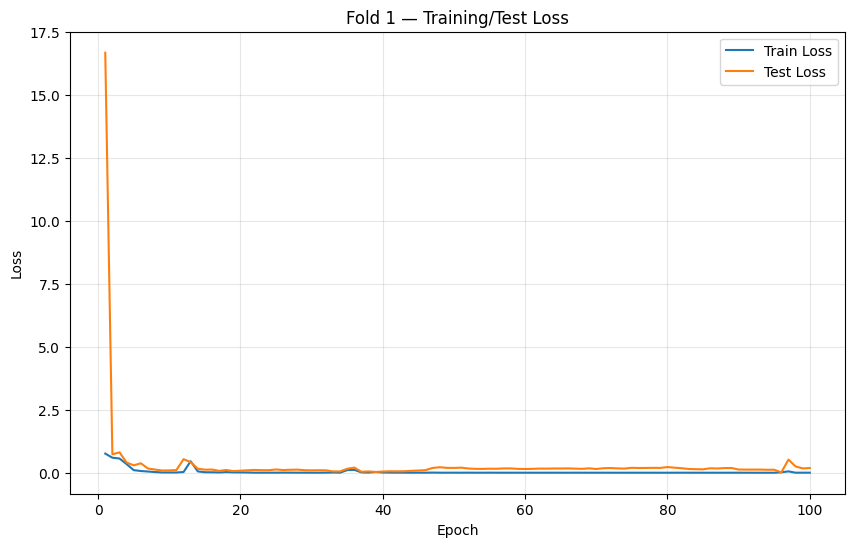

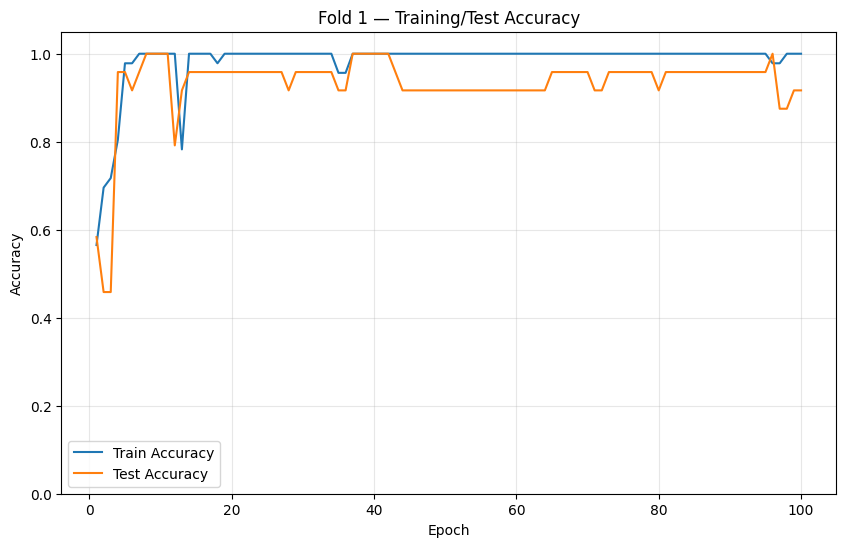

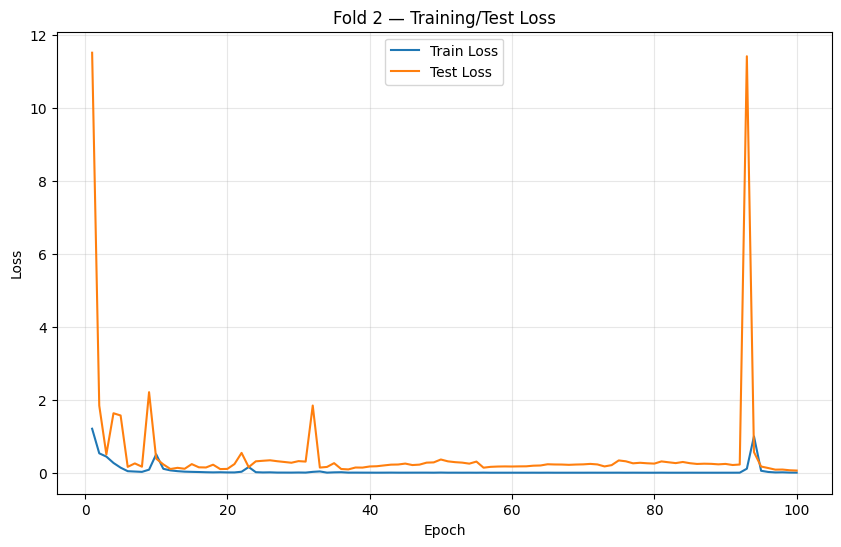

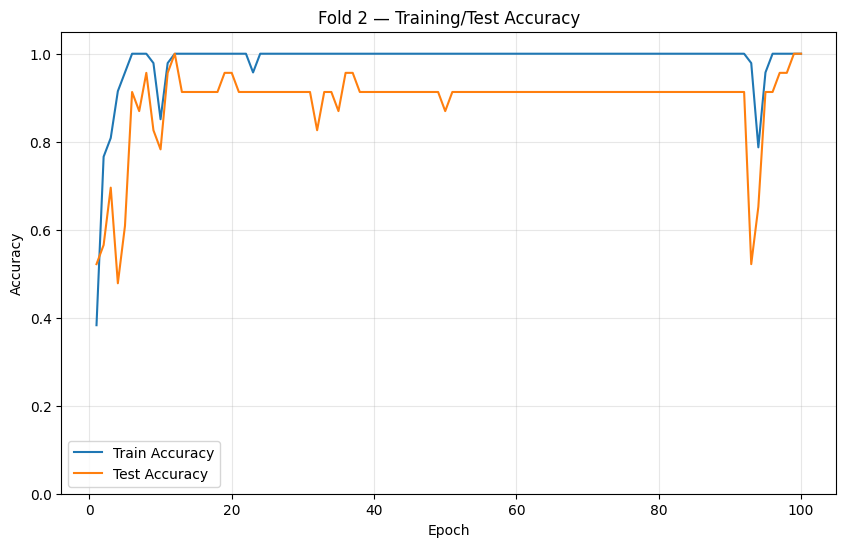

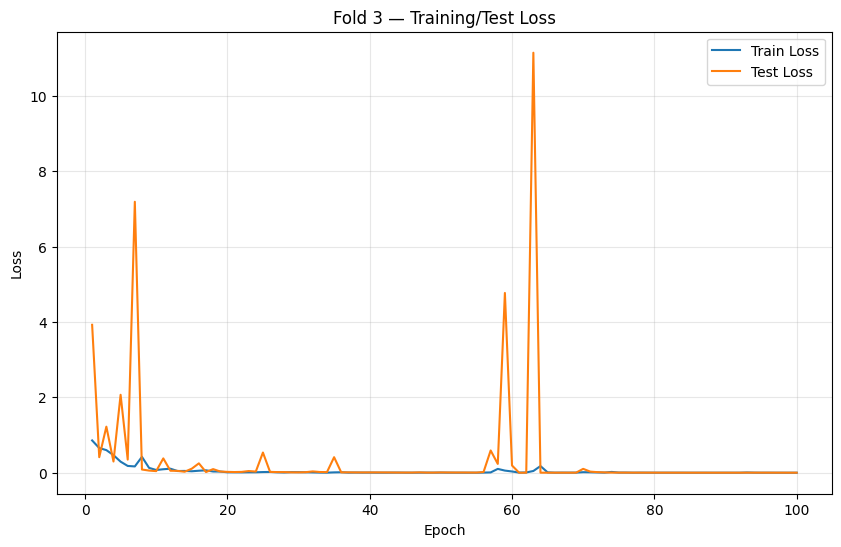

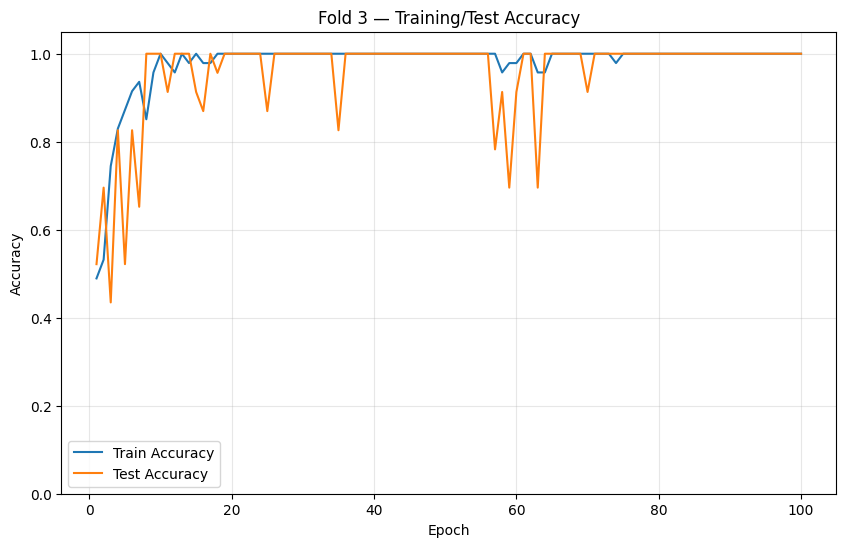

In [ ]:
# CELL 23 — PLOT TRAIN/TEST CURVES
# ============================================================

for result in fold_results:
    fold_id = result["fold"]
    history = result["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_id} — Training/Test Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["test_accuracy"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title(f"Fold {fold_id} — Training/Test Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ============================================================


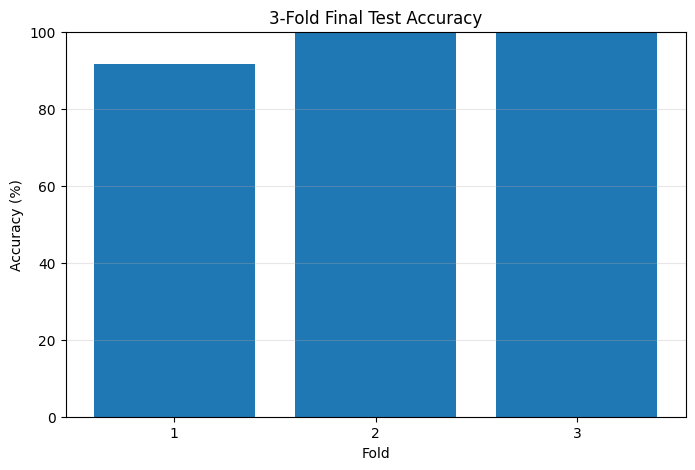

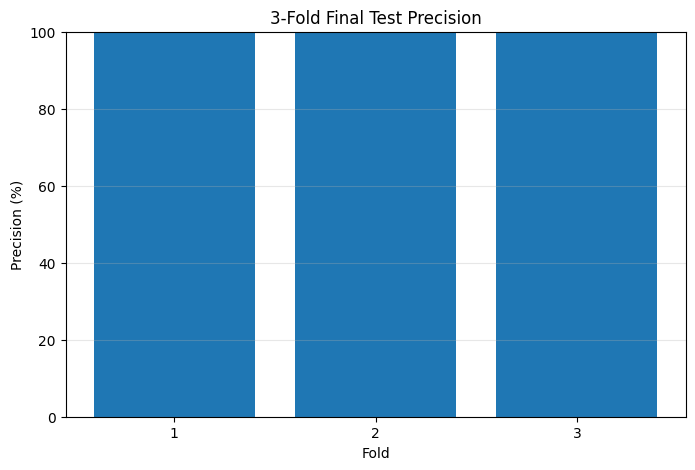

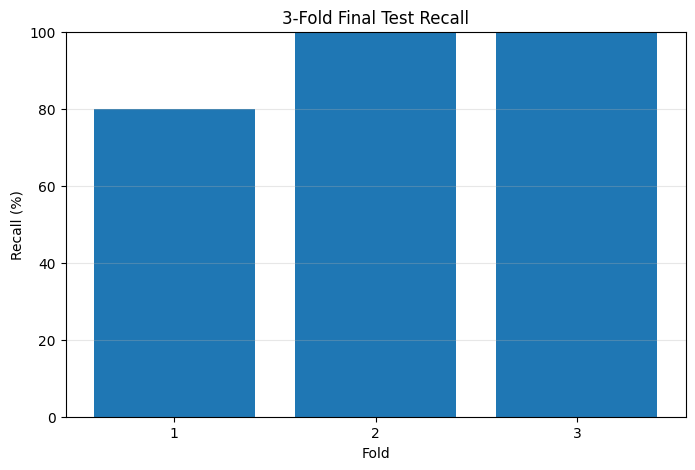

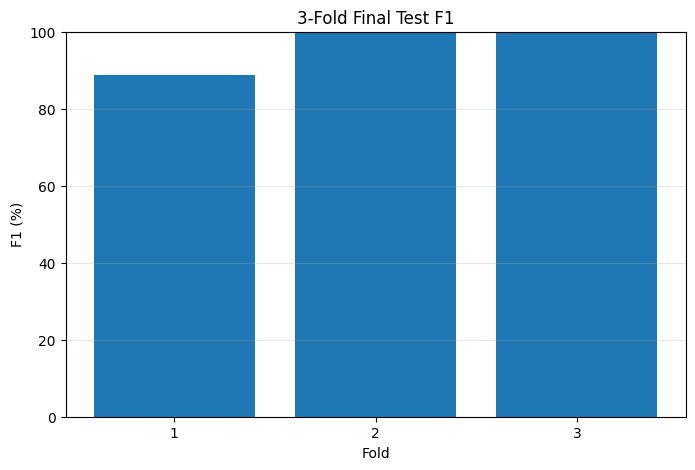

In [ ]:
# CELL 24 — PLOT FINAL FOLD METRICS
# ============================================================

fold_ids = [result["fold"] for result in fold_results]

for metric, label in zip(metrics, metric_labels):
    values = np.asarray(values_by_metric[metric]) * 100.0

    plt.figure(figsize=(8, 5))
    plt.bar(fold_ids, values)
    plt.xlabel("Fold")
    plt.ylabel(f"{label} (%)")
    plt.title(f"3-Fold Final Test {label}")
    plt.xticks(fold_ids)
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


# ============================================================


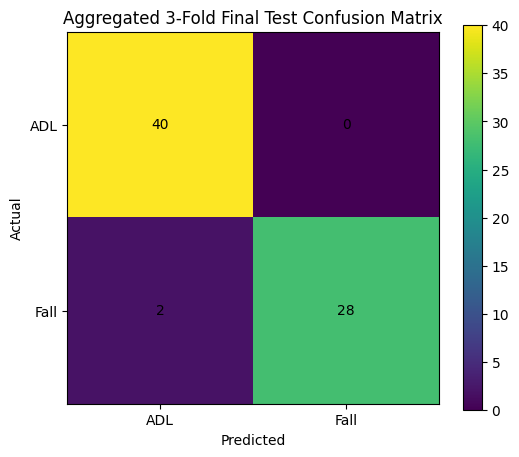

In [ ]:
# CELL 25 — PLOT AGGREGATED CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))
plt.imshow(aggregated_cm, interpolation="nearest")
plt.title("Aggregated 3-Fold Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["ADL", "Fall"])
plt.yticks([0, 1], ["ADL", "Fall"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, int(aggregated_cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()


# ============================================================


In [ ]:
# CELL 26 — SAVE FINAL SUMMARY
# ============================================================

summary_file = RESULTS_DIR / "gstcan_final_summary.pkl"
with open(summary_file, "wb") as f:
    pickle.dump(
        {
            "final_summary": final_summary,
            "aggregated_confusion_matrix": aggregated_cm.tolist(),
            "fold_results": fold_results,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print("\n========================================")
print("EXPERIMENT COMPLETE")
print("========================================")
print("Results:", results_file)
print("Summary:", summary_file)
print("Checkpoints:", CHECKPOINT_DIR)



EXPERIMENT COMPLETE
Results: /content/URFD/results_gstcan_fullseq/gstcan_3fold_results.pkl
Summary: /content/URFD/results_gstcan_fullseq/gstcan_final_summary.pkl
Checkpoints: /content/URFD/checkpoints_gstcan_fullseq
